## GROUP ONE

- M24B38/008 TRACY PAULA ADONGO
- S24B38/017 AGUME KENNETH
- S24B38/006 ALMUZAHIM NASEEF MUHAMAD
- M24B38/018 BABIRYE JOY LENAH
- S24B38/007 AYEBAZIBWE TRAVIS

As a group, we were given the field of health and biology. We chose the dataset The novel corona virus dataset from kaggle.
The dataset had over 300,000entries and 8 varibles. The workflow is shown below

## EXPLORING  AND PREPROCESSING THE DATASET

importing the libraries and dataset

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

In [4]:
df=pd.read_csv('covid_19_data.csv')
df

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0


- Statistical description of the dataset

In [26]:
df.describe()

,Confirmed,New_cases,log_new_cases
count,4.940000e+02,4.940000e+02,494.000000
mean,5.314181e+07,3.440307e+05,12.028051
std,5.289685e+07,2.551706e+05,1.891524
min,5.570000e+02,0.000000e+00,0.000000
25%,5.432008e+06,1.006088e+05,11.518967
50%,3.245885e+07,2.936535e+05,12.590159
75%,1.001883e+08,5.395918e+05,13.198570
max,1.699516e+08,1.498213e+06,14.219784


- Check Missing Values

In [27]:
df.isnull().sum()

Confirmed        0
New_cases        0
log_new_cases    0
dtype: int64

In [30]:
df.dtypes

Confirmed        float64
New_cases        float64
log_new_cases    float64
dtype: object

Due to the large size of the dataset, we couldnot easily insight from it, and the only variable that would be of use to us was the confirmed cases. As a group we decided to aggregate all entries under a certian date to get the summation. We then sorted the values because timeseries data falls chronological order,

In [5]:
df = df.groupby("ObservationDate")["Confirmed"].sum().reset_index()
df["ObservationDate"] = pd.to_datetime(df["ObservationDate"])
df = df.sort_values("ObservationDate")
df = df.set_index("ObservationDate")

We then created a new column of new cases, time series data works better with daily fluctuations, confirmed cases are aggregated and will not give us as much depth of the data. we clipped so that negative values are not involved

In [6]:
df["New_cases"] = df["Confirmed"].diff().fillna(0)
df["New_cases"] = df["New_cases"].clip(lower=0)  # remove negatives

WE then checked for the variance of the new cases , we noticed the variance was fluctuating and we therefore log transformed so stabilize it because one of the requirements while selcting a model is variance stabilization

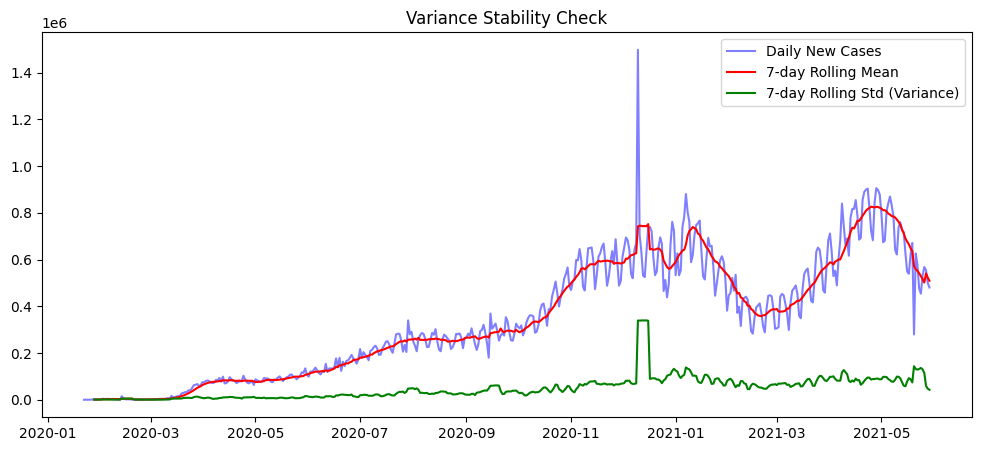

In [7]:
# Rolling statistics to check variance
rolling_mean = df["New_cases"].rolling(window=7).mean()
rolling_std = df["New_cases"].rolling(window=7).std()

plt.figure(figsize=(12,5))
plt.plot(df["New_cases"], label="Daily New Cases", color="blue", alpha=0.5)
plt.plot(rolling_mean, label="7-day Rolling Mean", color="red")
plt.plot(rolling_std, label="7-day Rolling Std (Variance)", color="green")
plt.title("Variance Stability Check")
plt.legend()
plt.show()

We created a new column which was log transformed and we continued with that variable for further analysis

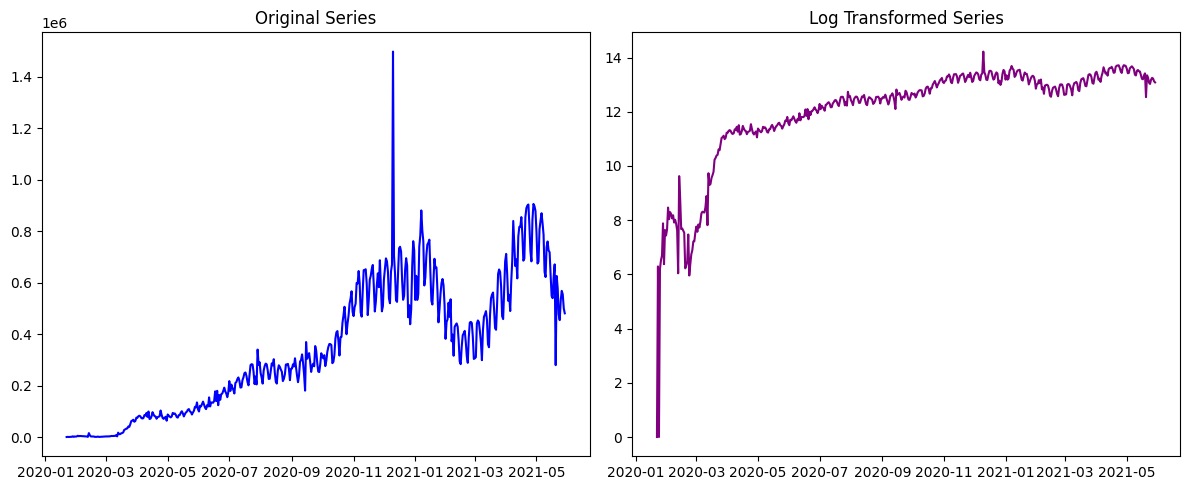

In [8]:
df["log_new_cases"] = np.log(df["New_cases"] + 1)

# Compare before vs after
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(df["New_cases"], color="blue")
plt.title("Original Series")
plt.subplot(1,2,2)
plt.plot(df["log_new_cases"], color="purple")
plt.title("Log Transformed Series")
plt.tight_layout()
plt.show()


## STATISTICAL DIAGNOSTICS

Carrying out the adf test, the adf test is a test used to test for stationarity.

It has a null and alternative hypothesis. The null hypothesis is the data is non stationary and the alternative is that its stationary

If the p-value>0.05  we fail to reject the null hypothesis and if its less than 0.05 we reject the null hypothesis meaning the series is stationary


In [9]:
result = adfuller(df["log_new_cases"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Critical Value {key}: {value}")


ADF Statistic: -3.7445348535760807
p-value: 0.003528597054465799
Critical Value 1%: -3.4441920863262863
Critical Value 5%: -2.8676439813617147
Critical Value 10%: -2.570021186703601


The log transformed series is stationary. This doesnt require us to difference though in some cases we have to difference like if the auto arima choose the most reliable model


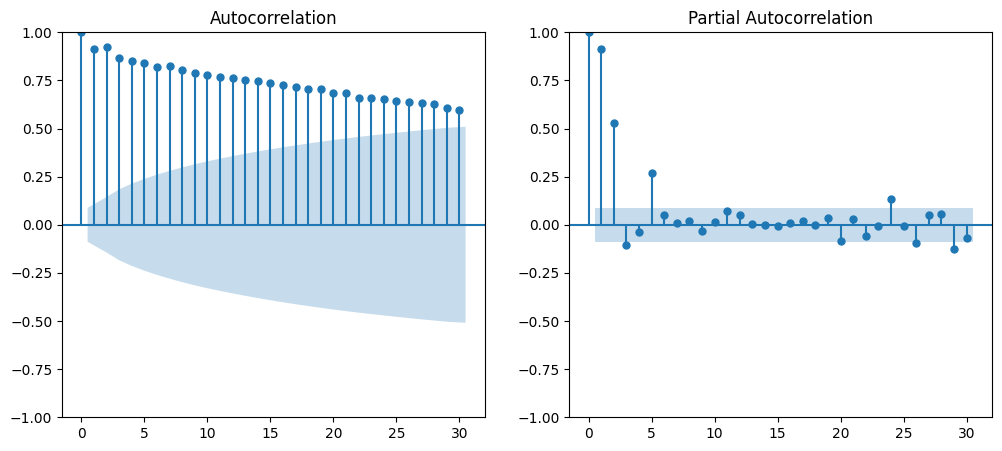

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
plot_acf(df["log_new_cases"],ax=ax[0], lags=30)

plot_pacf(df["log_new_cases"],ax=ax[1], lags=30)
plt.show()



## MILESTONE THREEE

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


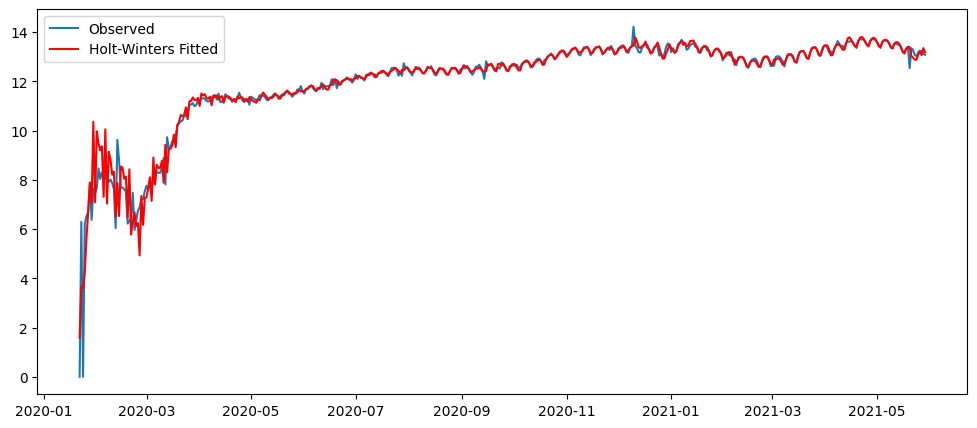

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

hw_model = ExponentialSmoothing(df["log_new_cases"],
                                trend="add", seasonal="add", seasonal_periods=7)
hw_fit = hw_model.fit()
plt.figure(figsize=(12,5))
plt.plot(df["log_new_cases"], label="Observed")
plt.plot(hw_fit.fittedvalues, label="Holt-Winters Fitted", color="red")
plt.legend()
plt.show()


In [12]:
print("Alpha (level):", hw_fit.params['smoothing_level'])
print("Beta (trend):", hw_fit.params['smoothing_trend'])
print("Gamma (seasonal):", hw_fit.params['smoothing_seasonal'])

Alpha (level): 0.3003617334450017
Beta (trend): 0.3003617334450017
Gamma (seasonal): 0.1969596807904321


The alpha level is concerned with how the model responds to recent data orgiving weight to recent data. A high alpha makes the model give more weight to newer data and a low alpha gives less weight or importance to historical data. This makes the model react to noise and be less smooth

The beta and gamma are connected with trend and seasonal soothing. A higher beta makes the series have a more reactive trend while a low beta makes the series have a less reactive trend

The higher the gamma the higher the change in its seasonal changes or seasonality

In conclusion , higher values of the parameters makes the model more sensitive to changes . if values are closer to one the model is more sensitive and values closer to zero keep the shape of the series

In [13]:
# 3.2 Auto ARIMA (seasonal)
auto_model = auto_arima(df["log_new_cases"],
                        seasonal=True, m=7, stepwise=True, suppress_warnings=True)
print(auto_model.summary())
print("Best ARIMA/SARIMA model:", auto_model.order, auto_model.seasonal_order)



                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  494
Model:             SARIMAX(1, 2, 2)x(1, 0, [1], 7)   Log Likelihood                -249.838
Date:                             Sat, 21 Mar 2026   AIC                            511.676
Time:                                     22:48:50   BIC                            536.867
Sample:                                 01-22-2020   HQIC                           521.568
                                      - 05-29-2021                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4935      0.014    -35.652      0.000      -0.521      -0.466
ma.L1         -1.3461      

In [14]:
diff2=df['log_new_cases'].diff().diff().dropna()
result = adfuller(diff2)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Critical Value {key}: {value}")


ADF Statistic: -11.178045380410202
p-value: 2.5416165758094597e-20
Critical Value 1%: -3.444250937448703
Critical Value 5%: -2.867669873870454
Critical Value 10%: -2.5700349866579657


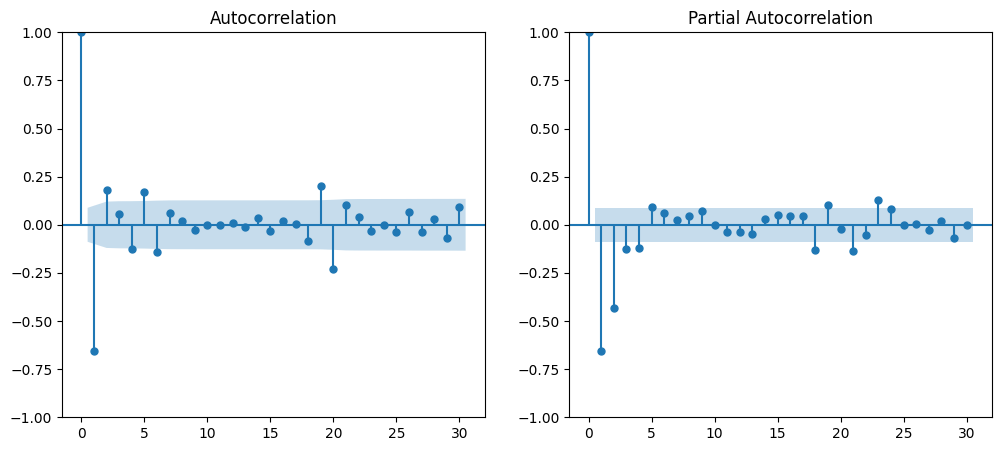

In [15]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
plot_acf(diff2,ax=ax[0], lags=30)

plot_pacf(diff2,ax=ax[1], lags=30)
plt.show()



In [16]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1,2,2)
arima_model = ARIMA(diff2.dropna(), order=(1,2,2))
arima_fit = arima_model.fit()

print("ARIMA(1,2,2) AIC:", arima_fit.aic)
print("ARIMA(1,2,2) BIC:", arima_fit.bic)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(1,2,2) AIC: 910.2317576191637
ARIMA(1,2,2) BIC: 927.0093791835824


In [17]:
# SARIMA(1,2,2)(1,0,1,7)
sarima_model = ARIMA(df["log_new_cases"].dropna(),
                     order=(1,2,2),
                     seasonal_order=(1,0,1,7))
sarima_fit = sarima_model.fit()

print("SARIMA(1,2,2)(1,0,1,7) AIC:", sarima_fit.aic)
print("SARIMA(1,2,2)(1,0,1,7) BIC:", sarima_fit.bic)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA(1,2,2)(1,0,1,7) AIC: 511.67606783174455
SARIMA(1,2,2)(1,0,1,7) BIC: 536.8669401306984


As seen earlier, the adf test gave us a value of 0.03. This technically means the series is stationary, but when we plotted acf plots, we could see the lags were nnot dying out quickly or slow decay. 

On model selection, we choose the auto arima we said the best arima model would be of order (1,2,2) and the sarima would be of order(1,2,2)(1,0,1,7). The sarima is capable of auto differencing that is why we didnt difference but the arima required a differencing of twice thats why for the model we used differenced data for the arima and original data for the sarima. From the comparison of the Akaike and Bayesian information criterion the sarima produced better values making it more balanced

This makes the model more parsimonious and better for model selction

## MILESTONE FOUR

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


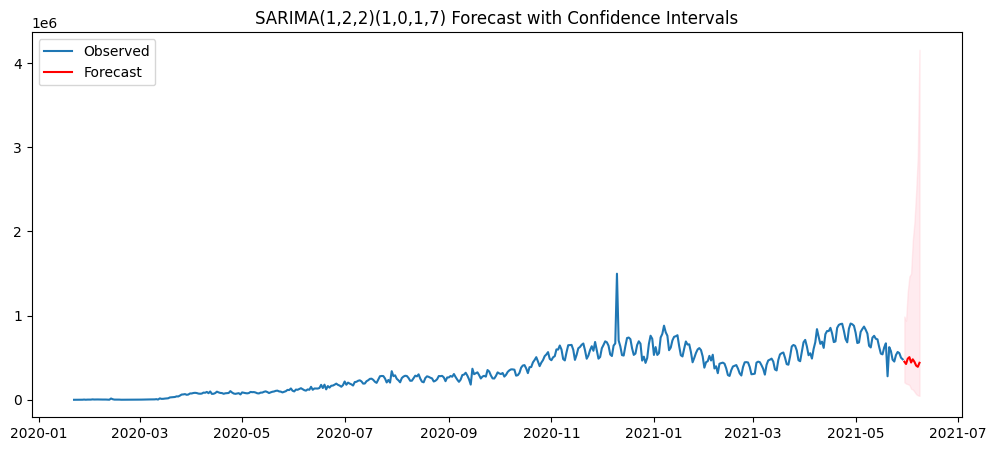

In [18]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# Fit SARIMA(1,2,2)(1,0,1,7) on full dataset
sarima_model = ARIMA(df["log_new_cases"].dropna(),
                     order=(1,2,2),
                     seasonal_order=(1,0,1,7))
final_fit = sarima_model.fit()

# Forecast 10 steps ahead
pred = final_fit.get_forecast(steps=10)

# Mean forecast and confidence intervals
forecast_mean = pred.predicted_mean
conf_int = pred.conf_int()

# Back-transform from log scale
forecast_actual = np.exp(forecast_mean)
conf_int_actual = np.exp(conf_int)

# Plot forecast with confidence intervals
plt.figure(figsize=(12,5))
plt.plot(np.exp(df["log_new_cases"]), label="Observed")
plt.plot(forecast_actual, label="Forecast", color="red")
plt.fill_between(conf_int_actual.index,
                 conf_int_actual.iloc[:,0],
                 conf_int_actual.iloc[:,1], color="pink", alpha=0.3)
plt.title("SARIMA(1,2,2)(1,0,1,7) Forecast with Confidence Intervals")
plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


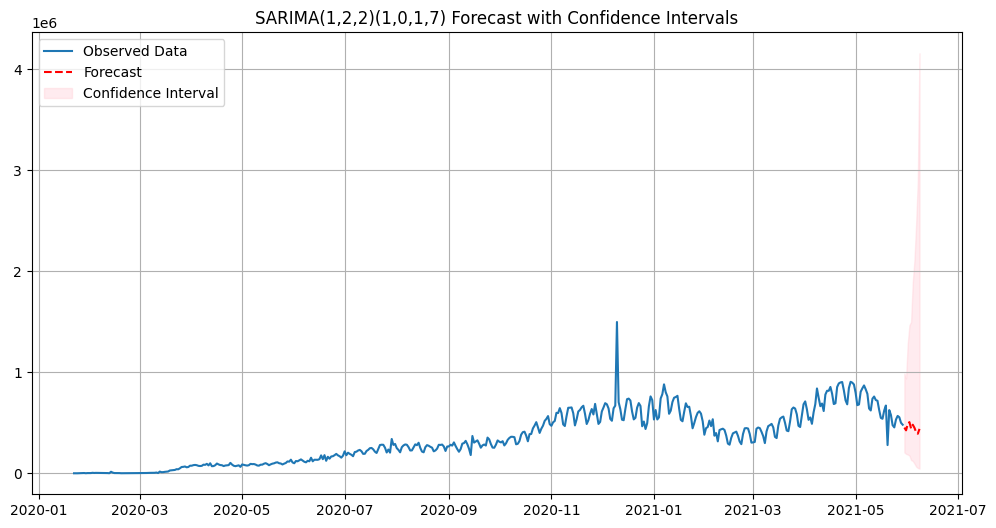

In [19]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# Fit SARIMA(1,2,2)(1,0,1,7) on full dataset
sarima_model = ARIMA(df["log_new_cases"].dropna(),
                     order=(1,2,2),
                     seasonal_order=(1,0,1,7))
model_fit = sarima_model.fit()

# Forecast 10 steps ahead
forecast_result = model_fit.get_forecast(steps=10)
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Back-transform to original scale
forecast_actual = np.exp(forecast)
conf_int_actual = np.exp(conf_int)
observed_actual = np.exp(df["log_new_cases"])

# Plot forecast with confidence intervals
plt.figure(figsize=(12,6))
plt.plot(observed_actual, label="Observed Data")
plt.plot(forecast_actual.index, forecast_actual, 
         color='red', linestyle='--', label="Forecast")
plt.fill_between(
    conf_int_actual.index,
    conf_int_actual.iloc[:,0],
    conf_int_actual.iloc[:,1],
    color='pink',
    alpha=0.3,
    label="Confidence Interval"
)
plt.title("SARIMA(1,2,2)(1,0,1,7) Forecast with Confidence Intervals")
plt.legend()
plt.grid(True)
plt.show()

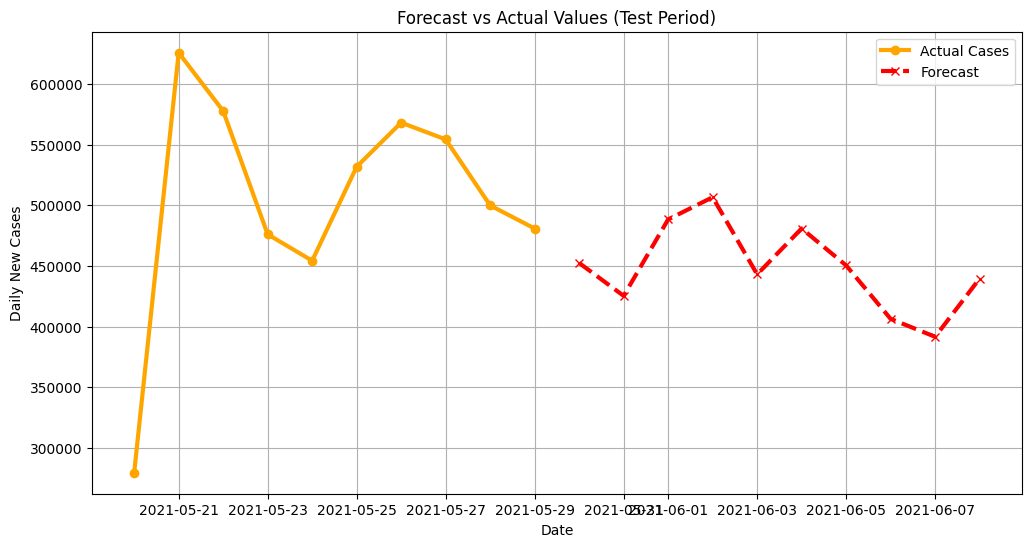

In [25]:
# Create a "test" set: last 10 days (or whatever number you want)
n_test = 10
test = df["log_new_cases"].iloc[-n_test:]  # just last 10 observations
forecast_result = final_fit.get_forecast(steps=n_test)
forecast = forecast_result.predicted_mean

# Back-transform if needed
test_actual = np.exp(test)
forecast_actual = np.exp(forecast)

# Plot using your original style
plt.figure(figsize=(12,6))
plt.plot(test_actual.index, test_actual, label="Actual Cases", 
         color="orange", linewidth=3, marker='o')
plt.plot(forecast_actual.index, forecast_actual, label="Forecast", 
         color="red", linewidth=3, linestyle="--", marker='x')
plt.title("Forecast vs Actual Values (Test Period)")
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train/test split (last 30 days as test)
n_test = 30
train, test = df["log_new_cases"].iloc[:-n_test], df["log_new_cases"].iloc[-n_test:]

# Fit SARIMA on training set
sarima_model = ARIMA(train, order=(1,2,2), seasonal_order=(1,0,1,7))
sarima_fit = sarima_model.fit()

# Forecast test period
forecast = sarima_fit.forecast(steps=n_test)

# Back-transform
forecast_actual = np.exp(forecast)
test_actual = np.exp(test)

# Accuracy metrics
mae = mean_absolute_error(test_actual, forecast_actual)
rmse = np.sqrt(mean_squared_error(test_actual, forecast_actual))
mape = np.mean(np.abs((test_actual - forecast_actual)/test_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 154449.9344419793
RMSE: 192033.45062960242
MAPE: 30.23827815107746


- MAPE shows the percentage of the predictions from the actual value. Our model was 30% off from the valid , this can be attributed to the fact that initially we had avergae cases that we aggregated and later subtracted so that we can get new cases. We also capped some values to zero removing daily fluctuation all these led to the moderate accuracy we got.

- This shows the data is suited for long term predictions or fluctuations not sudden bursts that we tried to adopt the variables to

- The root mean squared error shows the root of errors from the actual values, the 192042 shows how far off the predictions were. This can also be attributed to capped values and the overall nature of the data which were originally cummulative

The SARIMA follows the (p,d,q)(P,D,Q,m) so the SARIMA introduces the m which is the seasonal parameter this makes it more complex than a a traditional ARIMA. It usually struggles with epidemic and financial data.

The limitations are shown below;

SARIMA is sensitive to sudden changes for example lockdown. SARIMA works best random data that is stationary and struggles with non random data that has trend and seasonality.

SARIMA models face the issue of overfitting especially if the dataset is of small variables. This makes it learn all the data amd patterns making it less accurate towards new poor data